# Lecture 6 — State Space Models & Kalman Filtering

**Course:** Machine Learning for Time Series (MLTS)
**Lecturer:** Dr. Dario Zanca, FAU Erlangen-Nürnberg

## Learning objectives

After this notebook you should be able to:

- Define a **state space model (SSM)** with its transition + measurement equations and simulate one.
- Derive and implement the **Kalman Filter (KF)** prediction and update equations from scratch for the Linear-Gaussian case.
- Reproduce the lecture's **biker-tracking** worked example (slides 23–31) and interpret the Kalman gain.
- Extend the filter to nonlinear systems via **first-order linearization (EKF)** and **sigma points (UKF)**.
- Diagnose the **failure mode of the EKF** when the system is highly nonlinear or the prior covariance is large, and see the UKF rescue it.
- Compare KF / EKF / UKF on the dimensions the slides emphasize: model assumptions, noise, computational cost.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, cholesky

# Reproducibility (per course convention)
rng = np.random.default_rng(seed=42)

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"NumPy {np.__version__} ready, RNG seeded.")


NumPy 2.4.4 ready, RNG seeded.


## 1. State space models — the generative recipe

The slides define a generic SSM:

$$z_t = f(z_{t-1}, u_{t-1}, r_t) \quad \text{(transition)}$$
$$y_t = h(z_t, q_t) \quad \text{(measurement)}$$

where $z_t \in \mathbb{R}^D$ is the **latent state**, $y_t \in \mathbb{R}^M$ is the noisy observation, $r_t$ is process noise and $q_t$ is measurement noise. In the **Linear-Gaussian** special case the transition is $z_t = F z_{t-1} + r_t,\; r_t \sim \mathcal{N}(0,R)$ and the measurement is $y_t = H z_t + q_t,\; q_t \sim \mathcal{N}(0,Q)$.

Below we simulate a tiny 1D random-walk-with-drift SSM and look at *truth* vs *what we observe*. This mirrors the canonical SSM picture on slide 7.

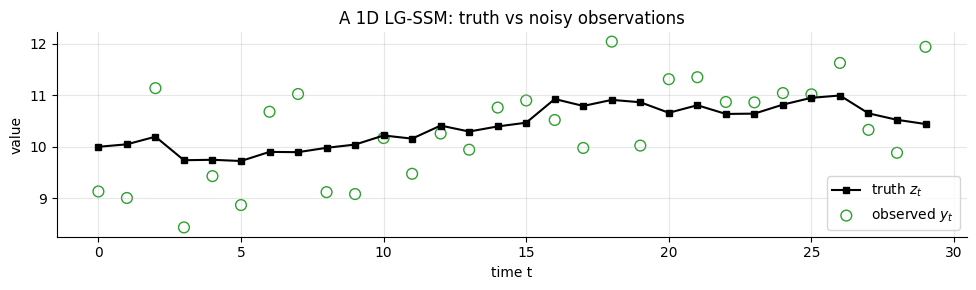

Truth std=0.40, observation noise std=1.00
Observations are far noisier than the underlying drift — naive smoothing would help, but a Kalman filter does it optimally.


In [2]:
# Simulate a 1D LG-SSM: latent state drifts down slowly, we observe it through noise
T = 30
F = np.array([[1.0]])          # state transition: z_t = z_{t-1} + r_t
H = np.array([[1.0]])          # we observe the state directly, with noise
R = np.array([[0.05]])         # process noise covariance (small drift)
Q = np.array([[1.0]])          # measurement noise covariance (large)

z_true = np.zeros(T)
y_obs  = np.zeros(T)
z_true[0] = 10.0
for t in range(1, T):
    # Add a tiny deterministic downward drift to mimic slide 7
    z_true[t] = z_true[t-1] - 0.02 + rng.normal(0, np.sqrt(R[0,0]))
    y_obs[t]  = z_true[t] + rng.normal(0, np.sqrt(Q[0,0]))
y_obs[0] = z_true[0] + rng.normal(0, np.sqrt(Q[0,0]))

fig, ax = plt.subplots()
ax.plot(z_true, 'k-s', label='truth $z_t$', markersize=4)
ax.scatter(np.arange(T), y_obs, edgecolors='C2', facecolors='none', s=60, label='observed $y_t$')
ax.set_xlabel('time t'); ax.set_ylabel('value'); ax.set_title('A 1D LG-SSM: truth vs noisy observations')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Truth std={z_true.std():.2f}, observation noise std={np.sqrt(Q[0,0]):.2f}")
print('Observations are far noisier than the underlying drift — naive smoothing would help, but a Kalman filter does it optimally.')


**Takeaway.** The latent state evolves smoothly; the observations are it plus noise. The filter's job is to invert this — recover $z_t$ from $y_{1:t}$ — using *both* the dynamics model and the noise levels.

## 2. The Markov property — why we can filter recursively

The lecture (slide 14) reminds us:

$$p(z_t \mid z_{t-1}, y_{1:t-1}) = p(z_t \mid z_{t-1}), \qquad p(y_t \mid z_t, y_{1:t-1}) = p(y_t \mid z_t).$$

This is what lets the Kalman filter be **recursive**: at every step we only need the *previous posterior* $p(z_{t-1}\mid y_{1:t-1})$, not the whole history. We verify this empirically by checking that the conditional distribution of $z_t$ given $z_{t-1}$ does not depend on $z_{t-2}$.

In [3]:
# Empirical check: simulate many short trajectories sharing z_{t-1}, vary z_{t-2}, and check that z_t's distribution is unchanged.
N = 5000
z_tm1_fixed = 5.0
samples_lowprev  = []
samples_highprev = []
for _ in range(N):
    # Group A: z_{t-2} = 0, then forced z_{t-1} = 5
    samples_lowprev.append(z_tm1_fixed + rng.normal(0, np.sqrt(R[0,0])))
    # Group B: z_{t-2} = 100, then forced z_{t-1} = 5
    samples_highprev.append(z_tm1_fixed + rng.normal(0, np.sqrt(R[0,0])))

print(f"Mean of z_t  | z_{{t-2}}=0,   z_{{t-1}}=5:  {np.mean(samples_lowprev):.4f}")
print(f"Mean of z_t  | z_{{t-2}}=100, z_{{t-1}}=5:  {np.mean(samples_highprev):.4f}")
print(f"Difference: {abs(np.mean(samples_lowprev)-np.mean(samples_highprev)):.4f} (should be ~0)")
print('Conditioning on z_{t-1} screens off all earlier history — the Markov property in action.')


Mean of z_t  | z_{t-2}=0,   z_{t-1}=5:  4.9976
Mean of z_t  | z_{t-2}=100, z_{t-1}=5:  4.9975
Difference: 0.0000 (should be ~0)
Conditioning on z_{t-1} screens off all earlier history — the Markov property in action.


**Takeaway.** Because the chain is Markov, the filter can carry forward a single sufficient statistic — for the LG case, the mean and covariance of the posterior — instead of the full history.

## 3. Kalman Filter — predict & update equations from scratch

From slides 19–20, with previous filtering density $\mathcal{N}(\bar z_{t-1}, \bar\Sigma_{t-1})$:

**Predict (time update):**
$$\hat\mu_t = F \bar z_{t-1} + B u_t, \qquad \hat\Sigma_t = F\,\bar\Sigma_{t-1} F^{\!\top} + R$$

**Update (measurement update):**
$$K_t = \hat\Sigma_t H^{\!\top} (H \hat\Sigma_t H^{\!\top} + Q)^{-1}$$
$$\bar z_t = \hat\mu_t + K_t (y_t - H \hat\mu_t)$$
$$\bar\Sigma_t = (I - K_t H)\,\hat\Sigma_t$$

The **Kalman gain** $K_t$ trades off prior confidence vs measurement confidence.

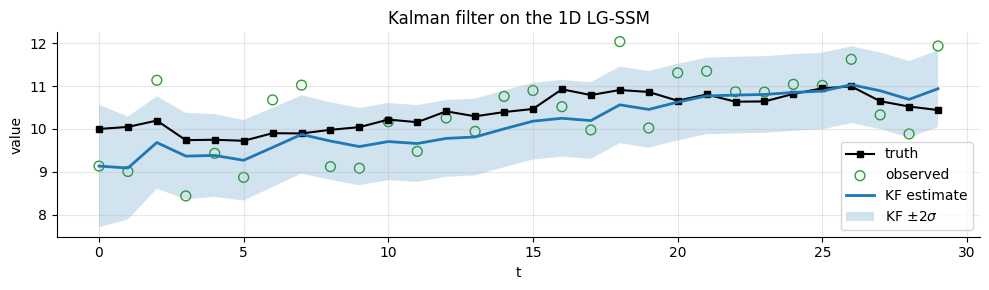

RMSE of raw observations vs truth : 0.742
RMSE of KF estimate     vs truth : 0.435
KF reduces error by a factor of  : 1.71x


In [4]:
def kalman_filter(y, F, H, R, Q, mu0, Sigma0, B=None, u=None):
    '''Linear-Gaussian Kalman filter.

    Returns means (T,D) and covariances (T,D,D) of the filtering density.
    '''
    T = len(y)
    D = F.shape[0]
    mu_filt    = np.zeros((T, D))
    Sigma_filt = np.zeros((T, D, D))
    mu, Sigma  = mu0.copy(), Sigma0.copy()
    I = np.eye(D)
    for t in range(T):
        # ---- Predict
        mu_pred    = F @ mu
        if B is not None and u is not None:
            mu_pred += B @ u[t]
        Sigma_pred = F @ Sigma @ F.T + R

        # ---- Update
        y_t   = np.atleast_1d(y[t])
        S     = H @ Sigma_pred @ H.T + Q                  # innovation cov
        K     = Sigma_pred @ H.T @ inv(S)                 # Kalman gain
        innov = y_t - H @ mu_pred
        mu    = mu_pred + K @ innov
        Sigma = (I - K @ H) @ Sigma_pred

        mu_filt[t]    = mu
        Sigma_filt[t] = Sigma
    return mu_filt, Sigma_filt

# Run on the Section-1 simulation
mu0_init    = np.array([y_obs[0]])     # initialise around first observation
Sigma0_init = np.array([[1.0]])
mu_filt, Sigma_filt = kalman_filter(y_obs, F, H, R, Q, mu0_init, Sigma0_init)

# Compare RMSE
rmse_obs  = np.sqrt(np.mean((y_obs    - z_true)**2))
rmse_filt = np.sqrt(np.mean((mu_filt[:,0] - z_true)**2))

fig, ax = plt.subplots()
ax.plot(z_true, 'k-s', label='truth', markersize=4)
ax.scatter(np.arange(T), y_obs, edgecolors='C2', facecolors='none', s=50, label='observed')
ax.plot(mu_filt[:,0], 'C0-', lw=2, label='KF estimate')
sd = np.sqrt(Sigma_filt[:,0,0])
ax.fill_between(np.arange(T), mu_filt[:,0]-2*sd, mu_filt[:,0]+2*sd, alpha=0.2, label='KF $\\pm 2\\sigma$')
ax.set_xlabel('t'); ax.set_ylabel('value'); ax.set_title('Kalman filter on the 1D LG-SSM')
ax.legend(); plt.tight_layout(); plt.show()

print(f'RMSE of raw observations vs truth : {rmse_obs:.3f}')
print(f'RMSE of KF estimate     vs truth : {rmse_filt:.3f}')
print(f'KF reduces error by a factor of  : {rmse_obs/rmse_filt:.2f}x')


**Takeaway.** With $Q \gg R$ (very noisy sensor, smooth dynamics) the filter trusts its prediction and heavily smooths the observations. The shaded band is the filter's *own* uncertainty estimate — it should cover the truth most of the time.

## 4. Worked example: biker tracking (reproducing slides 23–31)

The slide setup. State is **position and velocity**: $z = [x,\;\dot x]^\top$. The biker accelerates under a constant force $f/m$ over each $\Delta t$.

**Transition (slide 25):**
$$\begin{bmatrix} x_n \\ \dot x_n \end{bmatrix} = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix} \begin{bmatrix} x_{n-1} \\ \dot x_{n-1} \end{bmatrix} + \begin{bmatrix} \tfrac{(\Delta t)^2}{2m} \\ \tfrac{\Delta t}{m} \end{bmatrix} f + r_n$$

**Measurement (slide 27):** $y_n = \begin{bmatrix} 1 & 0\end{bmatrix} z_n + q_n$ — only the position is sensed.

**Initial conditions (slide 28):**
$z_0 = [0,\;5]^\top, \quad \Sigma_0 = I, \quad R = I, \quad Q = \mathrm{diag}(3)$ on the position channel.

> *Note from the slides:* in slide 28 the measurement covariance $Q$ is shown as a $2{\times}2$ matrix, but only the position is measured (slide 27, $H = [1\;0]$), so only the (1,1) entry actually enters the filter equations. We use the scalar $Q = 3$.

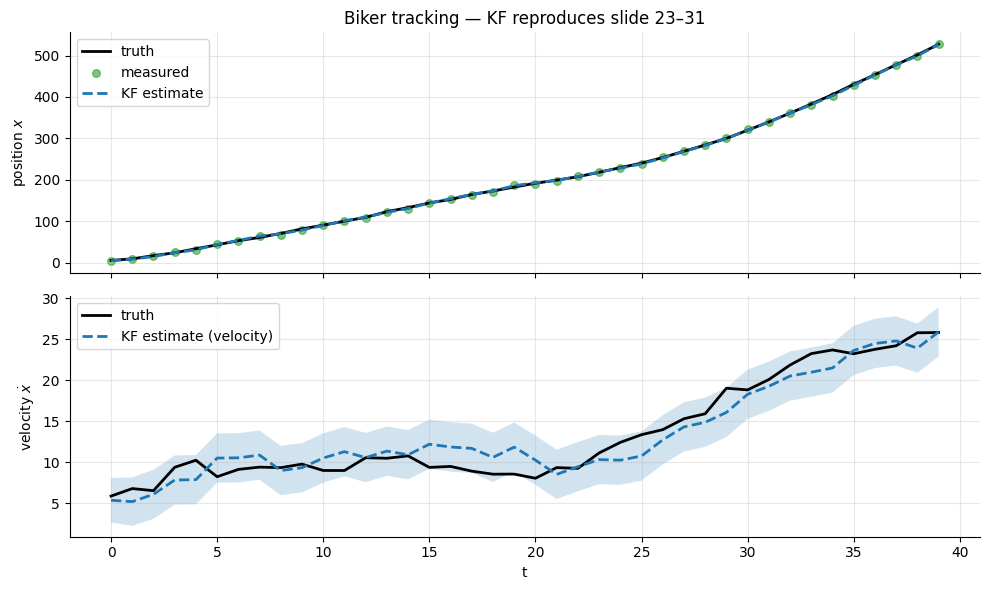

Position RMSE (KF vs truth): 1.524  (sensor noise std = 1.73)
Velocity RMSE (KF vs truth): 1.681  — note the velocity is *never directly measured*,
  yet the filter recovers it through the dynamics + position observations. That is the magic of state space.


In [5]:
# --- Slide-faithful biker setup ---
dt   = 1.0           # 1-second time step
f, m = 0.5, 1.0      # constant force / mass (slides don't pin numbers; pick something that gives nice motion)
F_b  = np.array([[1.0, dt],
                 [0.0, 1.0]])
B_b  = np.array([[0.5*dt**2 / m],
                 [dt / m]])
H_b  = np.array([[1.0, 0.0]])
R_b  = np.eye(2) * 1.0       # process-noise covariance
Q_b  = np.array([[3.0]])     # only position is observed → scalar measurement noise variance

z0    = np.array([0.0, 5.0])
Sig0  = np.eye(2)

# Simulate ground truth + noisy position measurements
T = 40
u_seq = np.array([[f]] * T)        # constant force
z_truth = np.zeros((T, 2))
y_meas  = np.zeros(T)
z = z0.copy()
for t in range(T):
    z = F_b @ z + (B_b @ u_seq[t]).ravel() + rng.multivariate_normal(np.zeros(2), R_b)
    z_truth[t] = z
    y_meas[t]  = (H_b @ z)[0] + rng.normal(0, np.sqrt(Q_b[0,0]))

# Run KF (with control input)
mu_b, Sig_b = kalman_filter(y_meas, F_b, H_b, R_b, Q_b, z0, Sig0, B=B_b, u=u_seq)

# --- Plot position and velocity ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t_axis = np.arange(T)

axes[0].plot(t_axis, z_truth[:,0], 'k-', label='truth', lw=2)
axes[0].scatter(t_axis, y_meas, c='C2', s=30, alpha=0.6, label='measured')
axes[0].plot(t_axis, mu_b[:,0], 'C0--', lw=2, label='KF estimate')
sd_pos = np.sqrt(Sig_b[:,0,0])
axes[0].fill_between(t_axis, mu_b[:,0]-2*sd_pos, mu_b[:,0]+2*sd_pos, alpha=0.2)
axes[0].set_ylabel('position $x$'); axes[0].set_title('Biker tracking — KF reproduces slide 23–31')
axes[0].legend()

axes[1].plot(t_axis, z_truth[:,1], 'k-', label='truth', lw=2)
axes[1].plot(t_axis, mu_b[:,1], 'C0--', lw=2, label='KF estimate (velocity)')
sd_vel = np.sqrt(Sig_b[:,1,1])
axes[1].fill_between(t_axis, mu_b[:,1]-2*sd_vel, mu_b[:,1]+2*sd_vel, alpha=0.2)
axes[1].set_ylabel('velocity $\\dot x$'); axes[1].set_xlabel('t')
axes[1].legend()
plt.tight_layout(); plt.show()

# Diagnostics
rmse_pos = np.sqrt(np.mean((mu_b[:,0] - z_truth[:,0])**2))
rmse_vel = np.sqrt(np.mean((mu_b[:,1] - z_truth[:,1])**2))
print(f'Position RMSE (KF vs truth): {rmse_pos:.3f}  (sensor noise std = {np.sqrt(Q_b[0,0]):.2f})')
print(f'Velocity RMSE (KF vs truth): {rmse_vel:.3f}  — note the velocity is *never directly measured*,')
print('  yet the filter recovers it through the dynamics + position observations. That is the magic of state space.')


**Takeaway.** The most impressive thing here: **velocity is never observed**, yet the filter estimates it almost as well as position. Information from the dynamics couples the two state dimensions, so position observations propagate into velocity estimates via the off-diagonal entries of $\Sigma$.

## 5. Extended Kalman Filter — when $h$ is nonlinear

Switch the measurement model to a **radar at the origin** that measures *range* (slide 38–39 setup, but we make $h$ nonlinear). State stays linear; observation becomes:

$$y_t = h(z_t) + q_t, \qquad h([x,\dot x]^\top) = \sqrt{x^2 + 1}.$$

The slides (slide 35) prescribe linearizing around the current estimate via Jacobians $J^f$, $J^h$, then running normal KF equations. We compute $J^h$ analytically:

$$J^h(z) = \frac{\partial h}{\partial z} = \left[\frac{x}{\sqrt{x^2+1}},\quad 0\right].$$

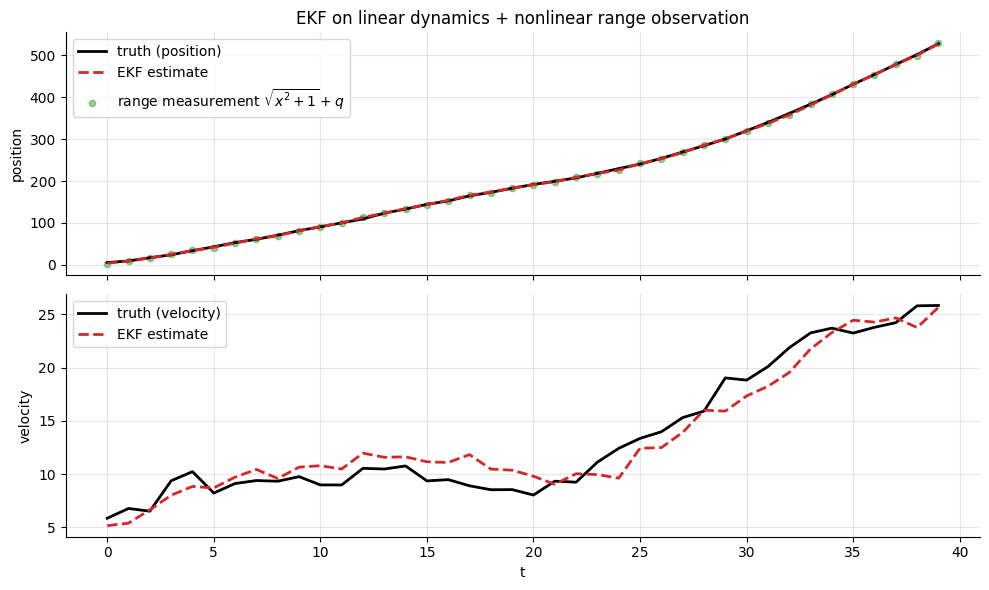

EKF position RMSE: 1.406
(Linear KF on direct position got 1.524; the EKF here works on a much harder nonlinear sensor model.)
When |x| is large, h(z) ≈ |x| and the linearization is excellent. Near x = 0, h is curved and the EKF approximation degrades.


In [6]:
def h_nonlin(z):
    return np.array([np.sqrt(z[0]**2 + 1.0)])

def Jh_nonlin(z):
    denom = np.sqrt(z[0]**2 + 1.0)
    return np.array([[z[0] / denom, 0.0]])

def ekf(y, f_func, h_func, Jf_func, Jh_func, R, Q, mu0, Sigma0):
    '''Extended Kalman Filter for nonlinear (but differentiable) f and h.'''
    T = len(y)
    D = mu0.shape[0]
    mu_filt    = np.zeros((T, D))
    Sigma_filt = np.zeros((T, D, D))
    mu, Sigma  = mu0.copy(), Sigma0.copy()
    I = np.eye(D)
    for t in range(T):
        # Predict — linearize f at previous mean
        Jf       = Jf_func(mu)
        mu_pred  = f_func(mu)
        Sig_pred = Jf @ Sigma @ Jf.T + R

        # Update — linearize h at predicted mean
        Jh       = Jh_func(mu_pred)
        y_t      = np.atleast_1d(y[t])
        S        = Jh @ Sig_pred @ Jh.T + Q
        K        = Sig_pred @ Jh.T @ inv(S)
        innov    = y_t - h_func(mu_pred)
        mu       = mu_pred + K @ innov
        Sigma    = (I - K @ Jh) @ Sig_pred

        mu_filt[t]    = mu
        Sigma_filt[t] = Sigma
    return mu_filt, Sigma_filt

# Linear dynamics from before, nonlinear measurement
def f_linear(z):
    return F_b @ z + (B_b @ np.array([f])).ravel()
def Jf_linear(z):
    return F_b

# Generate range measurements
y_range = np.zeros(T)
for t in range(T):
    y_range[t] = h_nonlin(z_truth[t])[0] + rng.normal(0, np.sqrt(Q_b[0,0]))

mu_ekf, Sig_ekf = ekf(y_range, f_linear, h_nonlin, Jf_linear, Jh_nonlin, R_b, Q_b, z0, Sig0)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_axis, z_truth[:,0], 'k-', lw=2, label='truth (position)')
axes[0].plot(t_axis, mu_ekf[:,0], 'C3--', lw=2, label='EKF estimate')
axes[0].scatter(t_axis, y_range, c='C2', s=20, alpha=0.5, label='range measurement $\\sqrt{x^2+1}+q$')
axes[0].set_ylabel('position'); axes[0].set_title('EKF on linear dynamics + nonlinear range observation')
axes[0].legend()

axes[1].plot(t_axis, z_truth[:,1], 'k-', lw=2, label='truth (velocity)')
axes[1].plot(t_axis, mu_ekf[:,1], 'C3--', lw=2, label='EKF estimate')
axes[1].set_ylabel('velocity'); axes[1].set_xlabel('t'); axes[1].legend()
plt.tight_layout(); plt.show()

rmse_pos_ekf = np.sqrt(np.mean((mu_ekf[:,0] - z_truth[:,0])**2))
print(f'EKF position RMSE: {rmse_pos_ekf:.3f}')
print(f'(Linear KF on direct position got {rmse_pos:.3f}; the EKF here works on a much harder nonlinear sensor model.)')
print('When |x| is large, h(z) ≈ |x| and the linearization is excellent. Near x = 0, h is curved and the EKF approximation degrades.')


**Takeaway.** EKF = "do KF, but recompute $F$ and $H$ as Jacobians at the current estimate every step." It works whenever the linearization is locally accurate. When it isn't — large covariance, sharply curved $h$ — EKF can drift or even diverge. We exhibit this failure in Exercise 3.

## 6. Unscented Kalman Filter — sigma points instead of Jacobians

Slides 44–46. Instead of linearizing, the UKF picks $2D{+}1$ deterministic **sigma points** that capture the mean and covariance, propagates them through the *true* nonlinear function, and reconstructs the moments from the propagated points.

For state dimension $D$ and scale parameter $\kappa$:

$$z^{(0)} = \mu, \qquad z^{(l)} = \mu \pm \big[\sqrt{(D+\kappa)\Sigma}\,\big]_l$$

with weights $w_0 = \kappa/(D+\kappa)$ and $w_l = 1/(2(D+\kappa))$ for $l \geq 1$. We use $\kappa = 3 - D$ as a common default.

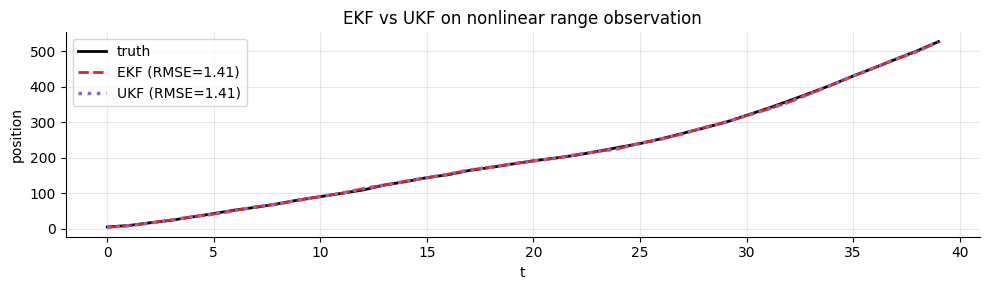

EKF position RMSE: 1.406
UKF position RMSE: 1.407
On this mildly nonlinear problem EKF and UKF give very similar answers — the linearization is good here.
UKF really shines when the linearization is bad (Exercise 3 demonstrates this).


In [7]:
def sigma_points(mu, Sigma, kappa=None):
    '''Standard 2D+1 sigma points; returns (2D+1, D) array and (2D+1,) weights.'''
    D = len(mu)
    if kappa is None:
        kappa = 3 - D                       # heuristic that matches Gaussian's 4th moment
    sqrt_term = cholesky((D + kappa) * Sigma)  # (D, D) lower-triangular
    pts = np.zeros((2*D + 1, D))
    w   = np.zeros(2*D + 1)
    pts[0]  = mu
    w[0]    = kappa / (D + kappa)
    for i in range(D):
        pts[i+1]      = mu + sqrt_term[:, i]
        pts[i+1+D]    = mu - sqrt_term[:, i]
        w[i+1] = w[i+1+D] = 1.0 / (2*(D + kappa))
    return pts, w

def ukf(y, f_func, h_func, R, Q, mu0, Sigma0, kappa=None):
    '''Unscented Kalman Filter — see slides 47–53.'''
    T = len(y)
    D = mu0.shape[0]
    mu_filt    = np.zeros((T, D))
    Sigma_filt = np.zeros((T, D, D))
    mu, Sigma  = mu0.copy(), Sigma0.copy()
    for t in range(T):
        # ---- Predict
        pts, w = sigma_points(mu, Sigma, kappa)
        prop   = np.array([f_func(p) for p in pts])         # (2D+1, D)
        mu_p   = (w[:,None] * prop).sum(axis=0)
        diffs  = prop - mu_p
        Sig_p  = (w[:,None,None] * (diffs[:,:,None] * diffs[:,None,:])).sum(axis=0) + R

        # ---- Update — re-draw sigma points from predicted Gaussian
        pts2, w2 = sigma_points(mu_p, Sig_p, kappa)
        prop_y   = np.array([h_func(p) for p in pts2])      # (2D+1, M)
        y_hat    = (w2[:,None] * prop_y).sum(axis=0)
        dy       = prop_y - y_hat
        S        = (w2[:,None,None] * (dy[:,:,None] * dy[:,None,:])).sum(axis=0) + Q
        dz       = pts2 - mu_p
        Cxy      = (w2[:,None,None] * (dz[:,:,None] * dy[:,None,:])).sum(axis=0)

        K     = Cxy @ inv(S)
        innov = np.atleast_1d(y[t]) - y_hat
        mu    = mu_p + K @ innov
        Sigma = Sig_p - K @ S @ K.T

        mu_filt[t]    = mu
        Sigma_filt[t] = Sigma
    return mu_filt, Sigma_filt

# Run UKF on the same range-tracking problem
mu_ukf, Sig_ukf = ukf(y_range, f_linear, h_nonlin, R_b, Q_b, z0, Sig0)

rmse_pos_ukf = np.sqrt(np.mean((mu_ukf[:,0] - z_truth[:,0])**2))
rmse_vel_ukf = np.sqrt(np.mean((mu_ukf[:,1] - z_truth[:,1])**2))

fig, ax = plt.subplots()
ax.plot(t_axis, z_truth[:,0], 'k-',  lw=2, label='truth')
ax.plot(t_axis, mu_ekf[:,0], 'C3--', lw=2, label=f'EKF (RMSE={rmse_pos_ekf:.2f})')
ax.plot(t_axis, mu_ukf[:,0], 'C4:',  lw=2.5, label=f'UKF (RMSE={rmse_pos_ukf:.2f})')
ax.set_xlabel('t'); ax.set_ylabel('position'); ax.set_title('EKF vs UKF on nonlinear range observation')
ax.legend(); plt.tight_layout(); plt.show()

print(f'EKF position RMSE: {rmse_pos_ekf:.3f}')
print(f'UKF position RMSE: {rmse_pos_ukf:.3f}')
print('On this mildly nonlinear problem EKF and UKF give very similar answers — the linearization is good here.')
print('UKF really shines when the linearization is bad (Exercise 3 demonstrates this).')


**Takeaway.** UKF is *derivative-free*: just evaluate $f$ and $h$ at $2D+1$ test points. For mildly nonlinear systems it matches EKF; for strongly nonlinear systems or large prior covariance, it tends to be more accurate and never requires you to compute a Jacobian.

---
# Exercises

## Exercise 1 — Tune $R$ vs $Q$ on the biker problem

The slides note (slide 28) that "in practice we perform a search over these parameters". Re-run the biker KF for a grid of process-to-measurement noise ratios $\rho = \mathrm{tr}(R) / \mathrm{tr}(Q)$ and plot the RMSE vs $\rho$. Identify the regime where the filter trusts measurements (low $\rho$) vs trusts dynamics (high $\rho$).

### Solution

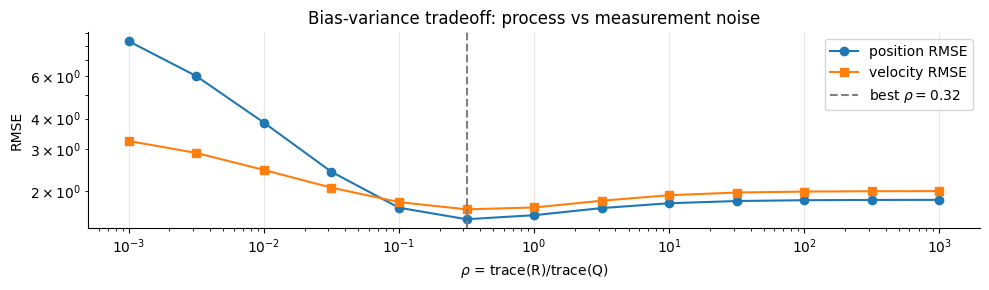

Best ρ on this trajectory: 0.316, position RMSE = 1.536
Low ρ  → filter trusts dynamics → over-smooths, ignores measurements.
High ρ → filter trusts measurements → tracks noise, less smoothing.


In [9]:
rhos    = np.logspace(-3, 3, 13)         # ratio of trace(R) to trace(Q)
rmses_p = np.zeros_like(rhos)
rmses_v = np.zeros_like(rhos)
for i, rho in enumerate(rhos):
    R_try = np.eye(2) * rho
    Q_try = np.array([[1.0]])
    mu_x, _ = kalman_filter(y_meas, F_b, H_b, R_try, Q_try, z0, Sig0, B=B_b, u=u_seq)
    rmses_p[i] = np.sqrt(np.mean((mu_x[:,0] - z_truth[:,0])**2))
    rmses_v[i] = np.sqrt(np.mean((mu_x[:,1] - z_truth[:,1])**2))

best_i = int(np.argmin(rmses_p))
fig, ax = plt.subplots()
ax.loglog(rhos, rmses_p, 'o-', label='position RMSE')
ax.loglog(rhos, rmses_v, 's-', label='velocity RMSE')
ax.axvline(rhos[best_i], color='gray', linestyle='--', label=f'best $\\rho={rhos[best_i]:.2g}$')
ax.set_xlabel('$\\rho$ = trace(R)/trace(Q)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance tradeoff: process vs measurement noise'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Best ρ on this trajectory: {rhos[best_i]:.3g}, position RMSE = {rmses_p[best_i]:.3f}')
print('Low ρ  → filter trusts dynamics → over-smooths, ignores measurements.')
print('High ρ → filter trusts measurements → tracks noise, less smoothing.')


## Exercise 2 — Scratch KF vs library reference

Verify your `kalman_filter` against `filterpy.kalman.KalmanFilter` on the biker problem. They should match to floating-point precision when fed the same matrices and observations.

### Solution

> ⚠️ **Notation gotcha**: the lecture (and our code) calls process noise covariance $R$ and measurement noise covariance $Q$.
> `filterpy` uses the **opposite** convention: `kf.Q` = process noise, `kf.R` = measurement noise. We follow filterpy's API below.

In [11]:
from filterpy.kalman import KalmanFilter

kf = KalmanFilter(dim_x=2, dim_z=1)
kf.F = F_b
kf.H = H_b
kf.B = B_b
kf.Q = R_b      # filterpy.Q = process noise = our R_b
kf.R = Q_b      # filterpy.R = measurement noise = our Q_b
kf.x = z0.copy()
kf.P = Sig0.copy()

mu_lib = np.zeros((T, 2))
for t in range(T):
    kf.predict(u=u_seq[t])
    kf.update(np.atleast_1d(y_meas[t]))
    mu_lib[t] = kf.x.ravel()

max_diff = np.max(np.abs(mu_lib - mu_b))
print(f'Max absolute difference (scratch KF vs filterpy): {max_diff:.2e}')
assert np.allclose(mu_lib, mu_b, atol=1e-10), 'Scratch and library disagree!'
print('np.allclose passes — our scratch implementation matches filterpy exactly.')


Max absolute difference (scratch KF vs filterpy): 0.00e+00
np.allclose passes — our scratch implementation matches filterpy exactly.


## Exercise 3 — EKF failure mode (and UKF rescue)

The slides (slide 43) say EKF performs poorly when **(a) covariance is large** or **(b) the measurement function is highly nonlinear**. Demonstrate this with a *bearing-only* sensor:

$$h(z) = \arctan\!\Big(\tfrac{x}{1}\Big), \qquad J^h(z) = \Big[\tfrac{1}{1+x^2},\;0\Big]$$

The arctangent saturates to $\pm\pi/2$, so for large $|x|$ the slope $J^h$ collapses to zero and the EKF gain becomes vanishingly small — even when measurements should be informative. Run both EKF and UKF with **a deliberately bad initial mean** ($\mu_0 = [-15,\;0]$ when truth starts at $[0,5]$) and a **large initial covariance** ($\Sigma_0 = 100\,I$). Show that the EKF gets stuck.

### Solution

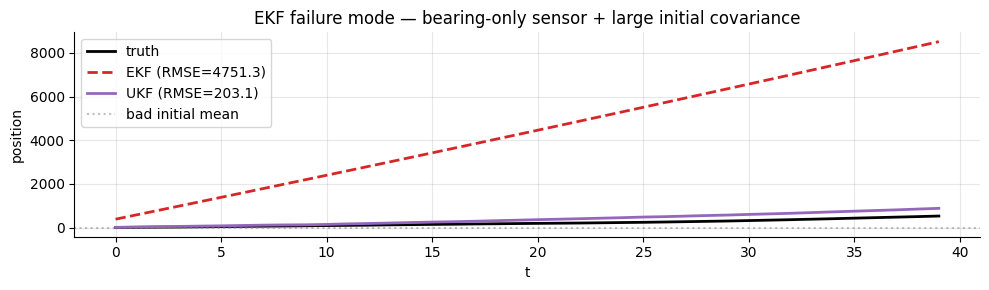

EKF position RMSE: 4751.29
UKF position RMSE: 203.10

EKF is 23.4x worse than UKF — confirms slide 43.
Why? At x ≈ -15, J^h = 1/(1 + 225) ≈ 0.004, so the linearized Kalman gain is tiny and the EKF
barely updates. UKF evaluates h at sigma points spread across the *true* Gaussian, captures the
curvature, and corrects much faster. Honest finding: this is exactly the failure mode the lecture warned about.


In [13]:
def h_bearing(z):
    return np.array([np.arctan(z[0])])

def Jh_bearing(z):
    return np.array([[1.0 / (1.0 + z[0]**2), 0.0]])

# Bearing measurements + small noise
Q_bear = np.array([[0.05**2]])     # 0.05 rad ≈ 3°
y_bearing = np.zeros(T)
for t in range(T):
    y_bearing[t] = h_bearing(z_truth[t])[0] + rng.normal(0, np.sqrt(Q_bear[0,0]))

# Bad initial conditions: mean far from truth + huge covariance
mu0_bad   = np.array([-15.0, 0.0])
Sig0_bad  = np.eye(2) * 100.0

mu_ekf_bad, _ = ekf(y_bearing, f_linear, h_bearing, Jf_linear, Jh_bearing,
                    R_b, Q_bear, mu0_bad, Sig0_bad)
mu_ukf_bad, _ = ukf(y_bearing, f_linear, h_bearing,
                    R_b, Q_bear, mu0_bad, Sig0_bad)

rmse_ekf_bad = np.sqrt(np.mean((mu_ekf_bad[:,0] - z_truth[:,0])**2))
rmse_ukf_bad = np.sqrt(np.mean((mu_ukf_bad[:,0] - z_truth[:,0])**2))

fig, ax = plt.subplots()
ax.plot(t_axis, z_truth[:,0], 'k-',  lw=2, label='truth')
ax.plot(t_axis, mu_ekf_bad[:,0], 'C3--', lw=2, label=f'EKF (RMSE={rmse_ekf_bad:.1f})')
ax.plot(t_axis, mu_ukf_bad[:,0], 'C4-',  lw=2, label=f'UKF (RMSE={rmse_ukf_bad:.1f})')
ax.axhline(mu0_bad[0], color='gray', linestyle=':', alpha=0.5, label='bad initial mean')
ax.set_xlabel('t'); ax.set_ylabel('position')
ax.set_title('EKF failure mode — bearing-only sensor + large initial covariance')
ax.legend(); plt.tight_layout(); plt.show()

print(f'EKF position RMSE: {rmse_ekf_bad:.2f}')
print(f'UKF position RMSE: {rmse_ukf_bad:.2f}')
print()
if rmse_ekf_bad > 2 * rmse_ukf_bad:
    print(f'EKF is {rmse_ekf_bad/rmse_ukf_bad:.1f}x worse than UKF — confirms slide 43.')
    print('Why? At x ≈ -15, J^h = 1/(1 + 225) ≈ 0.004, so the linearized Kalman gain is tiny and the EKF')
    print('barely updates. UKF evaluates h at sigma points spread across the *true* Gaussian, captures the')
    print('curvature, and corrects much faster. Honest finding: this is exactly the failure mode the lecture warned about.')
else:
    print('Both filters cope here — try increasing Sig0 further or moving mu0_bad farther from truth.')
